In [ ]:
import os, glob
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt

#find otomatic csv
candidates = []
for pattern in ["../data/**/*final*.csv", "../data/**/*merged*.csv", "../data/**/*processed*.csv", "../data/**/*.csv"]:

    candidates += glob.glob(pattern, recursive=True)

candidates = sorted(list(set(candidates)))
print("Found CSVs:", *candidates[:20], sep="\n- ")

#pick the most logical one
data_path = candidates[0]
df = pd.read_csv(data_path)

print("Using:", data_path)
df.shape, df.head()


Found CSVs:
- ../data\startup_dataset.csv
Using: ../data\startup_dataset.csv


((133, 11),
   startup_name    country  founded_year                  founders  \
 0       Airbnb         UK          2017  Founder Name Placeholder   
 1         Uber        UAE          2016  Founder Name Placeholder   
 2       Stripe     Turkey          2018  Founder Name Placeholder   
 3       SpaceX  Argentina          2003  Founder Name Placeholder   
 4      Revolut      India          2010  Founder Name Placeholder   
 
    founder_experience_years  team_size  total_funding_usd        sector  \
 0                        11       3517        12879110201        Health   
 1                        13       4111         6756338682        Health   
 2                        10       3553         3409353588        Health   
 3                        12       5607        14560499668      Delivery   
 4                         9        360         2315188091  Productivity   
 
     status  founder_count  gdp_growth  
 0  Success              4    1.551136  
 1  Success              3

In [ ]:
#find status
possible_status_cols = [c for c in df.columns if c.lower() in ["status", "company_status", "state", "outcome"]]
possible_status_cols


['status']

In [ ]:
STATUS_COL = possible_status_cols[0]  # gerekirse elle: STATUS_COL = "status"

#definition of success
success_map_1 = {"ipo":1, "acquired":1, "operating":1, "closed":0, "failed":0}

y_raw = df[STATUS_COL].astype(str).str.lower().str.strip()

#unknown labels
y = y_raw.map(success_map_1)

df_ml = df.copy()
df_ml["success"] = y

#hold the ones with label only
df_ml = df_ml.dropna(subset=["success"]).copy()
df_ml["success"] = df_ml["success"].astype(int)

df_ml["success"].value_counts(normalize=True)


Series([], Name: proportion, dtype: float64)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

df_ml = df.copy()

STATUS_COL = "status"
s = df_ml[STATUS_COL].astype(str).str.lower().str.strip()

df_ml["success"] = np.where(s == "success", 1,
                    np.where(s == "failure", 0, np.nan))

df_ml = df_ml.dropna(subset=["success"]).copy()
df_ml["success"] = df_ml["success"].astype(int)

y = df_ml["success"]
X = df_ml.drop(columns=["success", STATUS_COL], errors="ignore")

X = X.dropna(axis=1, how="all")

X = X.loc[y.index]
y = y.loc[X.index]

if len(X) == 0 or len(y) == 0:
    raise ValueError(f"Empty X or y after filtering. X={X.shape}, y={y.shape}")

if X.shape[1] == 0:
    X = pd.DataFrame({"dummy_feature": np.ones(len(y))}, index=y.index)

vc = y.value_counts()
if vc.shape[0] < 2:
    raise ValueError(f"Only one class present: {vc.to_dict()}")

test_size = 0.20
min_class = vc.min()
stratify_arg = y if min_class * test_size >= 1 else None

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=test_size,
    random_state=42,
    stratify=stratify_arg
)

print("X:", X.shape, "y:", y.shape, "counts:", vc.to_dict())
print("train:", X_train.shape, "test:", X_test.shape)


X: (112, 10) y: (112,) counts: {1: 76, 0: 36}
train: (89, 10) test: (23, 10)


In [ ]:
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ],
    remainder="drop"
)

len(num_cols), len(cat_cols)


(6, 4)

              precision    recall  f1-score   support

           0       0.33      0.43      0.38         7
           1       0.71      0.62      0.67        16

    accuracy                           0.57        23
   macro avg       0.52      0.53      0.52        23
weighted avg       0.60      0.57      0.58        23

ROC-AUC: 0.6607142857142857


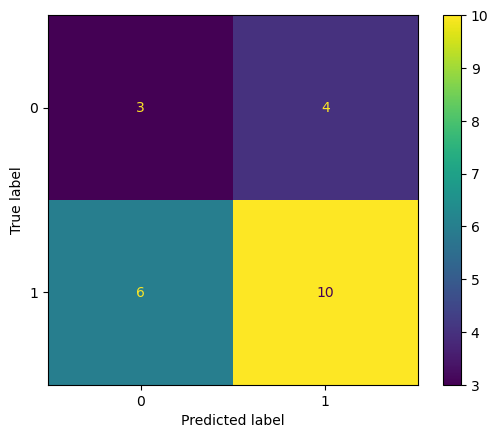

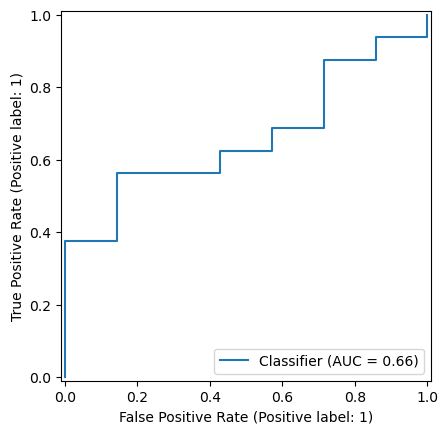

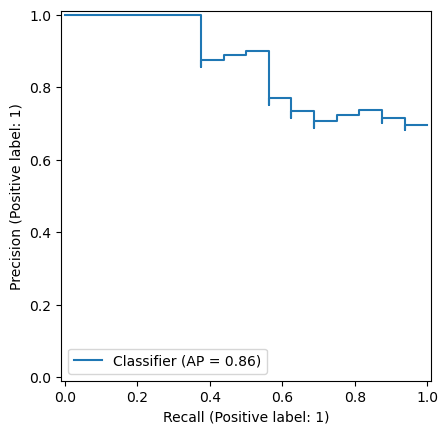

In [ ]:
logreg = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logreg.fit(X_train, y_train)
pred = logreg.predict(X_test)
proba = logreg.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred)).plot()
plt.show()

RocCurveDisplay.from_predictions(y_test, proba)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, proba)
plt.show()


In [ ]:
rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight="balanced_subsample",
        n_jobs=-1
    ))
])

proba = rf.predict_proba(X_test)[:, 1]

ths = np.linspace(0.05, 0.95, 19)
f1s = [f1_score(y_test, (proba >= t).astype(int)) for t in ths]
best_t = ths[int(np.argmax(f1s))]

pred_t = (proba >= best_t).astype(int)

print("Best threshold:", best_t)
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_t))
print(classification_report(y_test, pred_t, zero_division=0))

In [ ]:

proba = rf.predict_proba(X_test)[:, 1]

ths = np.linspace(0.05, 0.95, 19)
f1s = [f1_score(y_test, (proba >= t).astype(int)) for t in ths]
best_t = ths[int(np.argmax(f1s))]

pred_t = (proba >= best_t).astype(int)

print("Best threshold:", best_t)
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_t))
print(classification_report(y_test, pred_t, zero_division=0))


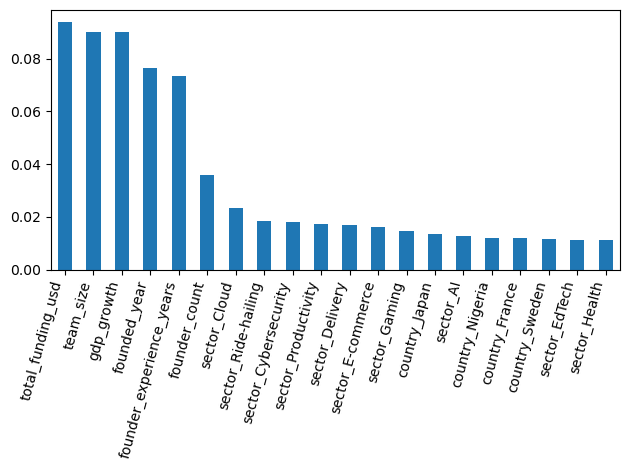

total_funding_usd           0.093771
team_size                   0.090128
gdp_growth                  0.089939
founded_year                0.076387
founder_experience_years    0.073461
founder_count               0.035733
sector_Cloud                0.023286
sector_Ride-hailing         0.018502
sector_Cybersecurity        0.018130
sector_Productivity         0.017341
sector_Delivery             0.016772
sector_E-commerce           0.016131
sector_Gaming               0.014784
country_Japan               0.013667
sector_AI                   0.012788
country_Nigeria             0.012030
country_France              0.011887
country_Sweden              0.011503
sector_EdTech               0.011361
sector_Health               0.011068
dtype: float64

In [ ]:
#featurre names after onehotencoding
ohe = rf.named_steps["prep"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

feature_names = np.concatenate([num_cols, cat_feature_names])

importances = rf.named_steps["model"].feature_importances_
imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

imp.plot(kind="bar")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

imp


In [ ]:
os.makedirs("figures/ml", exist_ok=True)
os.makedirs("data/predictions", exist_ok=True)

#png
test_out = pd.DataFrame({"y_true": y_test.values, "y_pred": pred, "y_proba": proba})
test_out.to_csv("data/predictions/test_predictions.csv", index=False)
test_out.head()


,y_true,y_pred,y_proba
0,1,1,0.7650
1,1,1,0.6025
2,1,1,0.6775
3,0,1,0.5650
4,1,1,0.7750
